## 1. Install dependencies

In [17]:
# torch is preinstalled on Colab. Install the quantum + ML + chem stack.
# PyTDC provides the official hERG dataset (Therapeutics Data Commons).
!pip install -q \
    qiskit qiskit-machine-learning qiskit-aer qiskit-algorithms \
    umap-learn scikit-learn transformers rdkit pandas PyTDC
print('\n✅ Dependencies installed. If a numpy/numba error appears below,'
      ' do Runtime → Restart session, then Run all again.')


✅ Dependencies installed. If a numpy/numba error appears below, do Runtime → Restart session, then Run all again.


## 2. Environment check

In [18]:
import torch, qiskit, sklearn, transformers
print('torch       :', torch.__version__, '| CUDA:', torch.cuda.is_available())
print('qiskit      :', qiskit.__version__)
print('scikit-learn:', sklearn.__version__)
print('transformers:', transformers.__version__)

torch       : 2.11.0+cu128 | CUDA: True
qiskit      : 2.5.0
scikit-learn: 1.6.1
transformers: 5.12.1


## 3. Write the pipeline module

Writes the **exact** `cardiotoxicity_pipeline.py` from the CardiogenAI repo to disk.

In [19]:
%%writefile cardiotoxicity_pipeline.py
"""
Hybrid Classical-Quantum Pipeline for Drug Cardiotoxicity Prediction
====================================================================

A two-stage hybrid **Classical-Quantum** pipeline that triages molecules for
cardiotoxicity (hERG / I_Kr blockade) and then discovers structural toxicity
sub-groups among the flagged molecules:

    SMILES strings
       |
       v
    [Step 1] LLM Semantic Extraction   ChemBERTa (DeepChem/ChemBERTa-77M-MTR)
       |                               -> dense (N, 384) chemical embeddings
       v
    [Step 2] Topological Compression   supervised UMAP -> n_qubits dimensions
       |                               (fit on train labels; test mapped label-free)
       v
    [Step 3] Quantum Kernel            bandwidth feature map (H, RZ(2c*z),
       |                               RZZ(2c^2*z_m*z_n); NO (pi-z) offsets)
       |                               fidelity |<phi(x)|phi(y)>|^2  OR projected
       |                               (Bloch-vector Gaussian) kernel
       v
    [Step 4] Stage 1: Supervised       SVC(kernel='precomputed')  ==>  QSVC triage
       |          Binary label: 0 = Safe (non-blocker), 1 = Toxic (hERG blocker).
       |          Class balancing; bandwidth c + C + threshold chosen on a clean
       |          validation holdout (leakage-free); classical baselines on the
       |          same features and on raw ChemBERTa.
       v
    [Step 5] Stage 2: Unsupervised     SpectralClustering(affinity='precomputed')
                                       over the quantum-kernel sub-matrix of the
                                       predicted-toxic molecules -> structural
                                       toxicity sub-groups.

Real data, real model
----------------------
* **Model:** the pretrained ChemBERTa chemical language model is loaded from the
  Hugging Face Hub (no random-initialised stand-in).
* **Data:** an official hERG cardiotoxicity dataset from Therapeutics Data
  Commons -- by default **hERGCentral** (``herg_central``, label ``hERG_inhib``:
  a ~306,893-molecule electrophysiology screen, binary blockade) -- or
  ``herg_karim`` / ``hERG``, or any CSV you download (``local_path``). It is
  subsampled to a balanced working set for the O(N^2) quantum kernel. A curated
  panel of 30 named marketed drugs is also provided for interpretable checks.

Because a fidelity quantum kernel is O(N^2), the quantum stages run on a
balanced subsample (configurable). The classical baseline and cross-validation
quantify what the quantum path achieves relative to a strong classical model.

Requirements
------------
    Python 3.10+
    pip install qiskit qiskit-machine-learning qiskit-aer scikit-learn \
                umap-learn transformers torch pandas rdkit

Network: Step 1 downloads ChemBERTa from ``huggingface.co`` (cached after first
run). The hERG data comes from an official source of your choice -- Therapeutics
Data Commons (``pip install PyTDC``) by default, or any CSV you download and
pass via ``local_path`` (see ``load_herg_dataset``).

Author: CardiogenAI
"""

from __future__ import annotations

import logging
import os
import tarfile
from dataclasses import dataclass, field

import numpy as np
import torch
from sklearn.cluster import SpectralClustering
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.svm import SVC
from transformers import AutoModel, AutoTokenizer

import umap

from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.quantum_info import Statevector

# --- Qiskit version-compatibility shim ------------------------------------- #
# Qiskit 2.x replaced the V1 ``Sampler`` with ``StatevectorSampler`` and
# deprecated the ``ZZFeatureMap`` class in favour of the ``zz_feature_map``
# function. Prefer the modern API and fall back for Qiskit 1.x installs.
try:  # Qiskit >= 1.3
    from qiskit.circuit.library import zz_feature_map as _zz_feature_map
except ImportError:  # Qiskit < 1.3
    from qiskit.circuit.library import ZZFeatureMap as _zz_feature_map

# The fidelity primitive is used only for the optional hardware-compatible
# kernel path; the default kernel is an exact statevector computation.
try:  # Qiskit 2.x
    from qiskit.primitives import StatevectorSampler as _Sampler
    from qiskit_machine_learning.state_fidelities import ComputeUncompute
    from qiskit_machine_learning.kernels import FidelityQuantumKernel
    _HAS_FIDELITY = True
except ImportError:  # pragma: no cover - Qiskit 1.x
    try:
        from qiskit.primitives import Sampler as _Sampler
        from qiskit_algorithms.state_fidelities import ComputeUncompute
        from qiskit_machine_learning.kernels import FidelityQuantumKernel
        _HAS_FIDELITY = True
    except ImportError:
        _HAS_FIDELITY = False

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)-7s | %(name)s | %(message)s",
    datefmt="%H:%M:%S",
)
logger = logging.getLogger("cardiotox_qml")


# --------------------------------------------------------------------------- #
# Configuration
# --------------------------------------------------------------------------- #
@dataclass
class PipelineConfig:
    """Central hyperparameter registry for the full hybrid pipeline."""

    # --- Step 1: ChemBERTa embedding ---
    model_name: str = "DeepChem/ChemBERTa-77M-MTR"
    max_token_length: int = 128
    embedding_batch_size: int = 32
    pooling: str = "mean"  # "mean" (masked mean), "cls", or "pooler"

    # --- Step 2: dimensionality compression ---
    n_qubits: int = 8               # compressed dim == number of qubits (8/12/16)
    compressor: str = "umap"        # "umap" or "pca"
    umap_n_neighbors: int = 15
    umap_min_dist: float = 0.1
    umap_metric: str = "cosine"
    # Supervised UMAP shapes the embedding with class labels (train only; test is
    # mapped label-free via transform()). NOTE: doing so pre-optimises the space
    # for Euclidean/distance kernels -- i.e. it helps the classical controls the
    # quantum map competes with. Set umap_supervised=False (or compressor='pca')
    # for a front-end that does not favour distance kernels.
    umap_supervised: bool = True
    umap_target_weight: float = 0.5

    # --- Step 3: Quantum feature map / kernel ---
    # Feature map (per rep): H on all qubits; single-qubit phase 2*alpha*z_k;
    # coupling phase 2*beta*z_m*z_n on wired pairs. alpha and beta are DECOUPLED
    # (not beta = alpha^2), so the coupling term is not welded to a tiny number.
    # reps>=2 breaks the r=1 closed form (uniform-amplitude phase state) where the
    # fidelity kernel is just a squared-distance machine and the projected kernel
    # is an RBF on angles -- expressivity starts at reps=2.
    feature_map_reps: int = 2
    entanglement: str = "full"      # "linear", "circular", "full", or "mutual_info"
    kernel_type: str = "projected"  # "projected" (Huang et al. 2021) or "fidelity"
    projected_order: int = 2        # 1 = single-qubit RDMs; 2 = + two-qubit RDMs
    alpha_scale: float = 1.0        # single-qubit phase scale (fallback if not tuned)
    beta_scale: float = 1.0         # coupling phase scale (fallback if not tuned)
    tune_alpha: tuple[float, ...] = (0.5, 1.0, 2.0)
    tune_beta: tuple[float, ...] = (0.0, 0.5, 1.0, 2.0)  # 0.0 => no coupling
    projected_gamma: float = 1.0    # multiplies a median-heuristic RBF width
    tune_gamma: tuple[float, ...] = (0.5, 1.0, 2.0)

    # --- Step 4: QSVC triage ---
    svc_C: float = 1.0
    tune_C: tuple[float, ...] = (0.1, 1.0, 10.0, 100.0)
    class_weight: str | None = "balanced"
    calibrate_threshold: bool = True
    run_classical_baseline: bool = True
    geometric_difference: bool = True     # screen g(K_classical || K_quantum)

    # --- Step 5: Spectral clustering ---
    n_clusters: int = 3

    # --- Data / split / reproducibility ---
    # NOTE: the exact statevector kernel holds 2**n_qubits complex amplitudes per
    # molecule, so peak memory ~ n_samples * 2**n_qubits * 16 bytes. With the
    # recommended n_qubits in 6-10, a few hundred to ~1000 molecules is fine.
    n_samples: int = 2500                  # balanced hERG working-set size
    max_quantum_samples: int = 2500       # hard cap on molecules in the quantum kernel
    test_size: float = 0.25
    val_size: float = 0.2                 # fraction of TRAIN held out for leakage-free
                                          # model selection (supervised UMAP is fit on
                                          # the remaining "fit" split only)
    random_state: int = 42


# --------------------------------------------------------------------------- #
# Step 1: Semantic Extraction (ChemBERTa LLM)
# --------------------------------------------------------------------------- #
class MoleculeEmbedder:
    """Wraps the pretrained ChemBERTa chemical language model to turn SMILES
    strings into dense molecular embeddings of shape (N, Hidden_Dim) -- 384 for
    ``DeepChem/ChemBERTa-77M-MTR``.

    Pooling strategies (config.pooling):
        * "mean"   -- attention-masked mean of the final hidden states
                      (default: deterministic, uses only pretrained weights).
        * "cls"    -- final hidden state of the leading <s>/[CLS] token.
        * "pooler" -- the model's ``pooler_output`` head (falls back to masked
                      mean pooling if the checkpoint ships no pooler weights --
                      ChemBERTa-77M-MTR does not).
    """

    def __init__(self, config: PipelineConfig):
        self.config = config
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.tokenizer = None
        self.model = None  # loaded lazily on first embed() (or via load())

    def load(self) -> "MoleculeEmbedder":
        """Load the pretrained ChemBERTa tokenizer and encoder from the HF Hub.

        Raises a clear, actionable error if the weights cannot be obtained --
        there is deliberately no random-initialised fallback.
        """
        if self.model is not None:
            return self
        logger.info(
            "Loading ChemBERTa '%s' on device '%s' ...",
            self.config.model_name,
            self.device,
        )
        try:
            self.tokenizer = AutoTokenizer.from_pretrained(self.config.model_name)
            self.model = AutoModel.from_pretrained(self.config.model_name).to(self.device)
        except (OSError, EnvironmentError) as err:
            raise RuntimeError(
                f"Could not load pretrained model '{self.config.model_name}' "
                f"from the Hugging Face Hub ({err}). This pipeline requires the "
                "real ChemBERTa weights. Ensure the host can reach "
                "'huggingface.co', or pre-populate the HF cache (HF_HOME) / set "
                "HF_ENDPOINT to a reachable mirror, then retry."
            ) from err
        self.model.eval()
        logger.info(
            "ChemBERTa ready: hidden_dim=%d, vocab=%d, pooling='%s'",
            self.model.config.hidden_size,
            self.model.config.vocab_size,
            self.config.pooling,
        )
        return self

    @property
    def hidden_dim(self) -> int:
        if self.model is None:
            self.load()
        return int(self.model.config.hidden_size)

    @torch.no_grad()
    def embed(self, smiles: list[str]) -> np.ndarray:
        """Embed a list of SMILES strings into a dense (N, Hidden_Dim) array."""
        if not smiles:
            raise ValueError("MoleculeEmbedder.embed received an empty SMILES list.")
        if self.model is None:
            self.load()

        vectors: list[np.ndarray] = []
        bs = self.config.embedding_batch_size
        for start in range(0, len(smiles), bs):
            chunk = smiles[start : start + bs]
            encoded = self.tokenizer(
                chunk,
                padding=True,
                truncation=True,
                max_length=self.config.max_token_length,
                return_tensors="pt",
            ).to(self.device)
            outputs = self.model(**encoded)
            pooled = self._pool(outputs, encoded["attention_mask"])
            vectors.append(pooled.cpu().numpy())
            if len(smiles) > 200 and (start // bs) % 10 == 0:
                logger.info("  embedded %d / %d ...", min(start + bs, len(smiles)), len(smiles))

        embeddings = np.vstack(vectors).astype(np.float64)
        logger.info("Embedded %d molecules -> shape %s", len(smiles), embeddings.shape)
        return embeddings

    def _pool(self, outputs, attention_mask: torch.Tensor) -> torch.Tensor:
        """Reduce token-level hidden states to one vector per molecule."""
        strategy = self.config.pooling
        last_hidden = outputs.last_hidden_state  # (B, T, H)
        if strategy == "cls":
            return last_hidden[:, 0]
        if strategy == "pooler":
            pooler = getattr(outputs, "pooler_output", None)
            if pooler is not None:
                return pooler
            logger.warning("Checkpoint has no pooler_output; using masked mean pooling.")
        mask = attention_mask.unsqueeze(-1).to(last_hidden.dtype)  # (B, T, 1)
        summed = (last_hidden * mask).sum(dim=1)
        counts = mask.sum(dim=1).clamp(min=1e-9)
        return summed / counts


# --------------------------------------------------------------------------- #
# Step 2: Topological Compression (UMAP)
# --------------------------------------------------------------------------- #
class TopologicalCompressor:
    """Compresses ChemBERTa embeddings to `n_qubits` dimensions and MinMax-scales
    each feature to [0, 1] (the quantum feature map then applies alpha/beta).

    ``config.compressor``:
      * "umap" -- UMAP, optionally **supervised** (fit on train labels, transform
        test label-free). Supervised UMAP shapes the space by Euclidean distance,
        which *helps the classical distance-kernel controls* -- use "pca" or
        umap_supervised=False for a front-end that does not pre-favour them.
      * "pca"  -- plain PCA (unsupervised, label-agnostic front-end).
    """

    def __init__(self, config: PipelineConfig):
        self.config = config
        if config.compressor == "pca":
            from sklearn.decomposition import PCA
            self.reducer = PCA(n_components=config.n_qubits,
                               random_state=config.random_state)
        else:
            self.reducer = umap.UMAP(
                n_neighbors=config.umap_n_neighbors,
                min_dist=config.umap_min_dist,
                n_components=config.n_qubits,
                metric=config.umap_metric,
                target_weight=config.umap_target_weight,
                random_state=config.random_state,
            )
        self.scaler = MinMaxScaler(feature_range=(0.0, 1.0))
        self._fitted = False

    def fit_transform(self, X_train: np.ndarray, y_train=None) -> np.ndarray:
        supervised = (self.config.compressor == "umap"
                      and self.config.umap_supervised and y_train is not None)
        logger.info("Fitting %s %s: %s -> %d dims",
                    "supervised" if supervised else "unsupervised",
                    self.config.compressor.upper(), X_train.shape, self.config.n_qubits)
        reduced = (self.reducer.fit_transform(X_train, y=np.asarray(y_train))
                   if supervised else self.reducer.fit_transform(X_train))
        scaled = self.scaler.fit_transform(reduced)
        self._fitted = True
        return scaled.astype(np.float64)

    def transform(self, X: np.ndarray) -> np.ndarray:
        if not self._fitted:
            raise RuntimeError("Call fit_transform on training data first.")
        reduced = self.reducer.transform(X)
        scaled = self.scaler.transform(reduced)
        return np.clip(scaled, 0.0, 1.0).astype(np.float64)


# --------------------------------------------------------------------------- #
# Step 3: Quantum Feature Map & Kernel
# --------------------------------------------------------------------------- #
def _wiring_pairs(n_qubits: int, entanglement: str,
                  features: np.ndarray | None = None) -> list[tuple[int, int]]:
    """Entangling edges. 'full' = all C(n,2) pairs; 'linear'/'circular' = a chain;
    'mutual_info' = the top-n_qubits feature pairs by mutual information (so the
    couplings connect actually-correlated coordinates, not arbitrary neighbours)."""
    if entanglement == "full":
        return [(i, j) for i in range(n_qubits) for j in range(i + 1, n_qubits)]
    if entanglement == "mutual_info" and features is not None:
        from sklearn.metrics import mutual_info_score
        binned = np.stack([
            np.digitize(features[:, j], np.histogram_bin_edges(features[:, j], bins=8))
            for j in range(n_qubits)], axis=1)
        scored = sorted(
            (((i, j), mutual_info_score(binned[:, i], binned[:, j]))
             for i in range(n_qubits) for j in range(i + 1, n_qubits)),
            key=lambda t: -t[1])
        return [p for p, _ in scored[:n_qubits]]
    pairs = [(i, i + 1) for i in range(n_qubits - 1)]           # linear
    if entanglement == "circular" and n_qubits > 2:
        pairs.append((n_qubits - 1, 0))
    return pairs


def _geometric_difference(K_classical: np.ndarray, K_quantum: np.ndarray,
                          reg: float = 1e-4) -> float:
    """Huang et al. (2021) asymmetric geometric difference

        g(K_C || K_Q) = sqrt( || sqrt(K_Q) (K_C + reg I)^-1 sqrt(K_Q) ||_inf ).

    Kernels are trace-normalised first. g near 1 means the classical kernel can
    reproduce anything the quantum kernel does on this data (no possible
    advantage from any labeling); large g is a *necessary* (not sufficient)
    condition for a quantum-kernel advantage."""
    def _norm(K):
        return K * (len(K) / np.trace(K))
    Kc, Kq = _norm(K_classical), _norm(K_quantum)
    w, V = np.linalg.eigh(Kq)
    sqrt_Kq = (V * np.sqrt(np.clip(w, 0.0, None))) @ V.T
    Kc_inv = np.linalg.inv(Kc + reg * np.eye(len(Kc)))
    M = sqrt_Kq @ Kc_inv @ sqrt_Kq
    return float(np.sqrt(np.linalg.norm(M, 2)))


class QuantumProcessor:
    """Data-encoding feature map + quantum kernel, redesigned to escape the r=1
    degeneracy where the "quantum" kernel is provably a classical squared-distance
    machine (fidelity) or an RBF-on-angles (projected).

    Feature map (per rep), inputs ``z`` in [0, 1], **decoupled** phase scales
    ``alpha`` (single-qubit) and ``beta`` (coupling):

        H on every qubit;  P(2*alpha*z_k) on qubit k;
        for each wired pair (m, n):  CX; P(2*beta*z_m*z_n); CX.

    reps >= 2 interleaves a second Hadamard+phase block, which breaks the
    uniform-amplitude closed form and produces non-trivial amplitudes / nonzero Z
    marginals -- where expressivity actually begins. No (pi - z) offsets.

    Kernels:
      * ``fidelity``  : K = |<phi(x)|phi(y)>|^2 (exact statevector).
      * ``projected`` : Gaussian on reduced-density-matrix (RDM) descriptors of
        |phi(.)> -- single-qubit (Bloch) and, with ``projected_order=2``, the
        two-qubit RDMs on the wired pairs (Huang et al. 2021). Structurally immune
        to global concentration, so it can run at O(1) phases.
    """

    def __init__(self, config: PipelineConfig, alpha: float | None = None,
                 beta: float | None = None, pairs: list[tuple[int, int]] | None = None):
        self.config = config
        self.n_qubits = config.n_qubits
        self.alpha = float(config.alpha_scale if alpha is None else alpha)
        self.beta = float(config.beta_scale if beta is None else beta)
        self.pairs = pairs if pairs is not None else _wiring_pairs(
            self.n_qubits, config.entanglement)
        self._z = ParameterVector("z", self.n_qubits)
        self.feature_map = self._build_feature_map()

    def _build_feature_map(self) -> QuantumCircuit:
        a, b, z = self.alpha, self.beta, self._z
        qc = QuantumCircuit(self.n_qubits)
        for _ in range(self.config.feature_map_reps):
            for k in range(self.n_qubits):
                qc.h(k)
                qc.p(2.0 * a * z[k], k)
            if b != 0.0:
                for (m, n) in self.pairs:
                    qc.cx(m, n)
                    qc.p(2.0 * b * z[m] * z[n], n)
                    qc.cx(m, n)
        return qc

    def states(self, X: np.ndarray) -> np.ndarray:
        """Simulate the feature map once per row; return (N, 2**n_qubits) complex."""
        dim = 2 ** self.n_qubits
        out = np.empty((len(X), dim), dtype=np.complex128)
        for i, x in enumerate(X):
            bound = self.feature_map.assign_parameters(
                {p: float(v) for p, v in zip(self._z, x)})
            out[i] = Statevector.from_instruction(bound).data
        return out

    # --- Pauli algebra on statevector batches (little-endian) --------------- #
    @staticmethod
    def _apply_pauli(states, k, which, idx):
        partner = idx ^ (1 << k)
        bit = (idx >> k) & 1
        if which == "Z":
            return states * (1 - 2 * bit)[None, :]
        if which == "X":
            return states[:, partner]
        return (-1j * (1 - 2 * bit))[None, :] * states[:, partner]   # Y

    def _expval(self, states, ops, idx):
        t = states
        for (k, w) in ops:
            t = self._apply_pauli(t, k, w, idx)
        return np.real(np.sum(np.conj(states) * t, axis=1))

    def rdm_features(self, states: np.ndarray) -> np.ndarray:
        """Feature vector F such that ||F_i - F_j||^2 = sum_S ||rho_S(i)-rho_S(j)||_F^2
        over single-qubit subsystems S (and, if projected_order>=2, the two-qubit
        RDMs on the wired pairs). Verified against qiskit partial_trace."""
        idx = np.arange(states.shape[1])
        paulis = ("X", "Y", "Z")
        cols = []
        # single-qubit RDMs: ||drho||_F^2 = 1/2 ||dr||^2  -> scale Bloch by 1/sqrt2
        for k in range(self.n_qubits):
            for w in paulis:
                cols.append(self._expval(states, [(k, w)], idx) / np.sqrt(2.0))
        # two-qubit RDMs on the wired pairs: ||drho||_F^2 = 1/4 sum_{PQ!=II} dc^2
        if self.config.projected_order >= 2:
            for (m, n) in self.pairs:
                for w in paulis:                      # P (x) I
                    cols.append(self._expval(states, [(m, w)], idx) / 2.0)
                for w in paulis:                      # I (x) Q
                    cols.append(self._expval(states, [(n, w)], idx) / 2.0)
                for a in paulis:                      # P (x) Q
                    for c in paulis:
                        cols.append(self._expval(states, [(m, a), (n, c)], idx) / 2.0)
        return np.stack(cols, axis=1)

    @staticmethod
    def _sqdist(A, B):
        return np.clip((A ** 2).sum(1)[:, None] + (B ** 2).sum(1)[None, :]
                       - 2.0 * A @ B.T, 0.0, None)

    def median_width(self, F: np.ndarray) -> float:
        """Median-heuristic RBF scale: 1 / median(pairwise sq-distance)."""
        d = self._sqdist(F, F)
        med = np.median(d[~np.eye(len(F), dtype=bool)])
        return 1.0 / med if med > 0 else 1.0

    def kernel(self, X_a, X_b=None, gamma=None):
        """Quantum kernel between X_a and X_b (or X_a with itself)."""
        S_a = self.states(X_a)
        S_b = S_a if X_b is None else self.states(X_b)
        if self.config.kernel_type == "projected":
            F_a = self.rdm_features(S_a)
            F_b = F_a if X_b is None else self.rdm_features(S_b)
            g = self.median_width(F_a) * self.config.projected_gamma if gamma is None else gamma
            return np.exp(-g * self._sqdist(F_a, F_b))
        K = np.abs(S_a.conj() @ S_b.T) ** 2
        return np.clip(K, 0.0, 1.0)


# --------------------------------------------------------------------------- #
# Result container
# --------------------------------------------------------------------------- #
@dataclass
class PipelineResult:
    # Stage 1 (quantum QSVC, held-out test set)
    y_pred_test: np.ndarray
    y_score_test: np.ndarray
    threshold: float
    accuracy: float
    f1: float
    roc_auc: float
    report: str
    best_C: float
    cv_auc_mean: float
    cv_auc_std: float

    # Classical baseline (raw ChemBERTa embeddings)
    baseline: dict | None

    # Stage 2 (mechanism sub-groups over predicted-toxic molecules)
    toxic_index: np.ndarray
    cluster_labels: np.ndarray | None
    cluster_summary: dict | None

    # Bookkeeping
    order: np.ndarray
    n_train: int
    full_kernel: np.ndarray = field(repr=False, default=None)

    # Quantum-kernel config + health
    alpha: float = 0.0               # selected single-qubit phase scale
    beta: float = 0.0                # selected coupling phase scale
    gamma: float = 0.0               # selected projected-kernel width multiplier
    kta: float = 0.0                 # kernel-target alignment
    offdiag_mean: float = 0.0        # mean off-diagonal kernel entry
    gdiff: float = 0.0               # geometric difference g(K_classical || K_quantum)


# --------------------------------------------------------------------------- #
# Steps 4 & 5: two-stage hybrid pipeline
# --------------------------------------------------------------------------- #
class ToxicityPipeline:
    """End-to-end orchestrator (Steps 1-5). Uses a fit/val/test split so the
    supervised UMAP, encoding bandwidth, SVC C, and decision threshold are all
    chosen on a validation set the embedding never saw (leakage-free), with the
    QSVC benchmarked against classical baselines on the identical features."""

    def __init__(self, config: PipelineConfig | None = None):
        self.config = config or PipelineConfig()
        self.embedder = MoleculeEmbedder(self.config)
        self.compressor = TopologicalCompressor(self.config)
        self.quantum = QuantumProcessor(self.config)
        self.classifier: SVC | None = None

    # ---- kernel cross-validation helpers ---------------------------------- #
    @staticmethod
    def _kta(K, y):
        """Centered kernel-target alignment: how well K's geometry matches the
        labels. KTA = <K, yy^T> / (||K|| ||yy^T||), with y in {-1,+1}."""
        yy = np.outer(y, y).astype(float)
        num = float((K * yy).sum())
        den = float(np.linalg.norm(K) * np.linalg.norm(yy))
        return num / den if den > 0 else 0.0

    def _select_hyperparams(self, X_fit, y_fit, X_val, y_val, pairs):
        """Grid-search the DECOUPLED phase scales (alpha, beta), the projected
        kernel width (gamma), and SVC C -- scored on the clean validation set
        (leakage-free: the supervised UMAP only saw the fit set). Representations
        (statevectors / RDM features) are computed once per (alpha, beta); gamma
        and C are then cheap."""
        cfg = self.config
        proj = cfg.kernel_type == "projected"
        a_grid, b_grid = cfg.tune_alpha or (cfg.alpha_scale,), cfg.tune_beta or (cfg.beta_scale,)
        g_grid = (cfg.tune_gamma or (cfg.projected_gamma,)) if proj else (1.0,)
        C_grid = cfg.tune_C or (cfg.svc_C,)
        y_fit_signed = np.where(y_fit == 1, 1.0, -1.0)
        best = {"auc": -np.inf, "alpha": a_grid[0], "beta": b_grid[0], "gamma": g_grid[0],
                "C": C_grid[0], "val_scores": None, "kta": 0.0, "off": 0.0, "gdiff": np.nan}

        for a in a_grid:
            for b in b_grid:
                qp = QuantumProcessor(cfg, alpha=a, beta=b, pairs=pairs)
                if proj:
                    S_f, S_v = qp.states(X_fit), qp.states(X_val)
                    F_f, F_v = qp.rdm_features(S_f), qp.rdm_features(S_v)
                    base_w = qp.median_width(F_f)
                    kernels = {g: (np.exp(-g * base_w * qp._sqdist(F_f, F_f)),
                                   np.exp(-g * base_w * qp._sqdist(F_v, F_f))) for g in g_grid}
                else:
                    S_f, S_v = qp.states(X_fit), qp.states(X_val)
                    Kff = np.clip(np.abs(S_f.conj() @ S_f.T) ** 2, 0.0, 1.0)
                    Kvf = np.clip(np.abs(S_v.conj() @ S_f.T) ** 2, 0.0, 1.0)
                    kernels = {1.0: (Kff, Kvf)}
                for g, (K_ff, K_vf) in kernels.items():
                    off = K_ff[~np.eye(len(K_ff), dtype=bool)]
                    kta = self._kta(K_ff, y_fit_signed)
                    for C in C_grid:
                        svc = SVC(kernel="precomputed", C=C, class_weight=cfg.class_weight)
                        svc.fit(K_ff, y_fit)
                        try:
                            vs = svc.decision_function(K_vf)
                            vauc = roc_auc_score(y_val, vs)
                        except ValueError:
                            vs, vauc = np.zeros(len(y_val)), 0.5
                        if vauc > best["auc"]:
                            best.update(auc=vauc, alpha=a, beta=b, gamma=g, C=C,
                                        val_scores=vs, kta=kta, off=float(off.mean()),
                                        K_ff=K_ff)
                logger.info("  alpha=%-4.2g beta=%-4.2g | off-diag mean=%.3g KTA=%.3f",
                            a, b, K_ff[~np.eye(len(K_ff), dtype=bool)].mean(), kta)

        # Geometric difference g(K_classical || K_quantum) on the fit block: is
        # there ANY labeling of this data for which the quantum kernel could beat
        # the classical RBF? (Huang et al. 2021). Large => potential advantage.
        if cfg.geometric_difference and "K_ff" in best:
            from sklearn.metrics.pairwise import rbf_kernel
            Kc = rbf_kernel(X_fit, X_fit, gamma=1.0 / X_fit.shape[1])
            best["gdiff"] = _geometric_difference(Kc, best["K_ff"])
        logger.info("Selected alpha=%.3g beta=%.3g gamma=%.3g C=%g (val AUC=%.4f, "
                    "g(K_C||K_Q)=%.2f)", best["alpha"], best["beta"], best["gamma"],
                    best["C"], best["auc"], best["gdiff"])
        return best

    def run(self, smiles, labels, names=None) -> PipelineResult:
        cfg = self.config
        labels = np.asarray(labels, dtype=int)
        names = list(names) if names is not None else [f"mol_{i}" for i in range(len(smiles))]

        # ---- cap quantum working set for tractability --------------------- #
        if len(smiles) > cfg.max_quantum_samples:
            idx = _balanced_subsample(labels, cfg.max_quantum_samples, cfg.random_state)
            smiles = [smiles[i] for i in idx]
            names = [names[i] for i in idx]
            labels = labels[idx]
            logger.info("Capped working set to %d molecules for the quantum kernel.", len(smiles))

        # ---- stratified train/test split, then a clean validation holdout --- #
        # Supervised UMAP is fit on the FIT split only; VAL and TEST are embedded
        # label-free via transform(), so bandwidth/C/threshold are all chosen on
        # data the embedding never saw (no leakage). The final QSVC is trained on
        # FIT and evaluated on the untouched TEST set.
        idx_train, idx_test = train_test_split(
            np.arange(len(smiles)), test_size=cfg.test_size,
            stratify=labels, random_state=cfg.random_state,
        )
        idx_fit, idx_val = train_test_split(
            idx_train, test_size=cfg.val_size, stratify=labels[idx_train],
            random_state=cfg.random_state,
        )
        order = np.concatenate([idx_fit, idx_val, idx_test])
        n_fit, n_val, n_test = len(idx_fit), len(idx_val), len(idx_test)
        n_train = n_fit + n_val
        smiles_ord = [smiles[i] for i in order]
        y_ord = labels[order]
        y_fit, y_val = y_ord[:n_fit], y_ord[n_fit:n_train]
        y_train, y_test = y_ord[:n_train], y_ord[n_train:]
        logger.info(
            "Working set: %d molecules (fit %d / val %d / test %d), toxic rate "
            "fit=%.2f val=%.2f test=%.2f", len(smiles), n_fit, n_val, n_test,
            y_fit.mean(), y_val.mean(), y_test.mean(),
        )

        # ---- Step 1: ChemBERTa embeddings --------------------------------- #
        logger.info("=== Step 1/5: ChemBERTa semantic extraction ===")
        E_all = self.embedder.embed(smiles_ord)
        E_fit, E_val, E_test = E_all[:n_fit], E_all[n_fit:n_train], E_all[n_train:]

        # ---- Step 2: compression (supervised UMAP / PCA, fit on FIT only) --- #
        logger.info("=== Step 2/5: topological compression (%s) ===", cfg.compressor)
        X_fit = self.compressor.fit_transform(E_fit, y_fit)
        X_val = self.compressor.transform(E_val)
        X_test = self.compressor.transform(E_test)
        X_all = np.vstack([X_fit, X_val, X_test])

        # entangling wiring (mutual-information edges are computed on fit features)
        pairs = _wiring_pairs(cfg.n_qubits, cfg.entanglement, X_fit)

        # ---- Step 3+4: (alpha,beta,gamma,C) selection on VAL, then final kernel #
        logger.info("=== Step 3/5: Quantum kernel + leakage-free selection ===")
        best = self._select_hyperparams(X_fit, y_fit, X_val, y_val, pairs)
        best_C, val_auc = best["C"], best["auc"]

        self.quantum = QuantumProcessor(cfg, alpha=best["alpha"], beta=best["beta"], pairs=pairs)
        # For the projected kernel, freeze the RBF width from the fit block so the
        # full kernel uses the exact width selected on validation.
        if cfg.kernel_type == "projected":
            base_w = self.quantum.median_width(self.quantum.rdm_features(self.quantum.states(X_fit)))
            K_full = self.quantum.kernel(X_all, gamma=best["gamma"] * base_w)
        else:
            K_full = self.quantum.kernel(X_all)
        K_full = np.clip((K_full + K_full.T) / 2.0, 0.0, 1.0)  # symmetrise
        K_fit = K_full[:n_fit, :n_fit]                         # fit-vs-fit (training)
        K_test_fit = K_full[n_train:, :n_fit]                  # test-vs-fit

        # Kernel-health diagnostic: off-diagonal distribution + KTA + geometric
        # difference vs a classical RBF (can any labeling favour the quantum kernel?).
        offdiag = K_full[~np.eye(len(K_full), dtype=bool)]
        pct = np.percentile(offdiag, [5, 25, 50, 75, 95])
        logger.info("Kernel off-diagonal: mean=%.4g pct[5,25,50,75,95]=%s max=%.4g | "
                    "KTA=%.4f  g(K_C||K_Q)=%.2f", offdiag.mean(),
                    np.round(pct, 4).tolist(), offdiag.max(), best["kta"], best["gdiff"])
        if offdiag.mean() < 1e-3:
            logger.warning("Quantum kernel is CONCENTRATED (near-identity, off-diag "
                           "mean=%.2g): reduce n_qubits/reps or raise beta.", offdiag.mean())
        elif offdiag.mean() > 0.98 and cfg.kernel_type == "fidelity":
            logger.warning("Quantum kernel is near-constant (off-diag mean=%.3g): the "
                           "feature map is too weak; raise alpha/beta.", offdiag.mean())

        # ---- Step 4: Stage 1 QSVC (train on FIT, threshold on VAL) --------- #
        logger.info("=== Step 4/5: Stage 1 - supervised QSVC triage ===")
        self.classifier = SVC(kernel="precomputed", C=best_C,
                              class_weight=cfg.class_weight)
        self.classifier.fit(K_fit, y_fit)

        # Threshold: Youden's J on the clean validation scores (model trained on
        # FIT, val embedded label-free). Same model/scale used for test below.
        threshold = 0.0
        if cfg.calibrate_threshold and best["val_scores"] is not None \
                and np.std(best["val_scores"]) > 1e-6:
            fpr, tpr, thr = roc_curve(y_val, best["val_scores"])
            threshold = float(thr[np.argmax(tpr - fpr)])
            logger.info("Calibrated decision threshold: %.4f (Youden's J on validation)", threshold)

        y_score_test = self.classifier.decision_function(K_test_fit)
        y_pred_test = (y_score_test >= threshold).astype(int)

        acc = accuracy_score(y_test, y_pred_test)
        f1 = f1_score(y_test, y_pred_test, zero_division=0)
        try:
            auc = roc_auc_score(y_test, y_score_test)
        except ValueError:
            auc = float("nan")
        report = classification_report(
            y_test, y_pred_test, target_names=["Safe (0)", "Toxic (1)"], zero_division=0,
        )
        logger.info("QSVC test: accuracy=%.4f  f1=%.4f  roc_auc=%.4f (val AUC=%.4f)",
                    acc, f1, auc, val_auc)

        # ---- classical baselines (fit-train, val-select, test-report) ------ #
        baseline = None
        if cfg.run_classical_baseline:
            baseline = self._classical_baseline(
                E_fit, y_fit, E_val, y_val, E_test, y_test,
                X_fit=X_fit, X_val=X_val, X_test=X_test)

        # ---- Step 5: Stage 2 mechanism sub-grouping ----------------------- #
        # Triage every molecule with the fit-trained QSVC (columns = fit block).
        logger.info("=== Step 5/5: Stage 2 - spectral mechanism discovery ===")
        y_pred_all = (self.classifier.decision_function(K_full[:, :n_fit]) >= threshold).astype(int)
        toxic_local = np.flatnonzero(y_pred_all == 1)
        toxic_index = order[toxic_local]
        cluster_labels, cluster_summary = None, None
        if len(toxic_local) >= cfg.n_clusters:
            affinity = np.clip(K_full[np.ix_(toxic_local, toxic_local)], 0.0, 1.0)
            spectral = SpectralClustering(
                n_clusters=cfg.n_clusters, affinity="precomputed",
                assign_labels="kmeans", random_state=cfg.random_state,
            )
            cluster_labels = spectral.fit_predict(affinity)
            cluster_summary = _characterise_clusters(
                [smiles[i] for i in toxic_index], cluster_labels, cfg.n_clusters
            )
            logger.info("Discovered %d sub-groups among %d predicted-toxic molecules: sizes=%s",
                        cfg.n_clusters, len(toxic_local),
                        np.bincount(cluster_labels, minlength=cfg.n_clusters).tolist())
        else:
            logger.warning("Only %d predicted-toxic molecules (< n_clusters=%d): skipping clustering.",
                           len(toxic_local), cfg.n_clusters)

        return PipelineResult(
            y_pred_test=y_pred_test, y_score_test=y_score_test, threshold=threshold,
            accuracy=acc, f1=f1, roc_auc=auc, report=report,
            best_C=best_C, cv_auc_mean=float(val_auc), cv_auc_std=0.0,
            baseline=baseline, toxic_index=toxic_index, cluster_labels=cluster_labels,
            cluster_summary=cluster_summary, order=order, n_train=n_train, full_kernel=K_full,
            alpha=float(best["alpha"]), beta=float(best["beta"]), gamma=float(best["gamma"]),
            kta=float(best["kta"]), offdiag_mean=float(offdiag.mean()), gdiff=float(best["gdiff"]),
        )

    def _classical_baseline(self, E_fit, y_fit, E_val, y_val, E_test, y_test,
                            X_fit=None, X_val=None, X_test=None) -> dict:
        """Classical baselines, trained/selected/reported on the SAME fit/val/test
        splits as the QSVC for a fair, leakage-free comparison:

        * ``rbf_umap`` / ``linsvc_umap`` -- classical SVC on the **same** UMAP
          features the quantum kernel sees (apples-to-apples control: quantum ZZ
          kernel vs classical kernel on identical n_qubits-d inputs).
        * ``rbf_384`` / ``logreg_384`` -- on the raw ChemBERTa embeddings, i.e.
          the ceiling you forgo by compressing to n_qubits dimensions.

        The reported ``cv_auc_mean`` is the clean **validation** AUC (comparable
        to the quantum val AUC); ``test_*`` are on the held-out test set.
        """
        cfg = self.config
        out = {}

        def _evaluate(name, model, fit_X, val_X, test_X):
            model.fit(fit_X, y_fit)
            def _score(Z):
                return (model.decision_function(Z) if hasattr(model, "decision_function")
                        else model.predict_proba(Z)[:, 1])
            try:
                val_auc = roc_auc_score(y_val, _score(val_X))
            except ValueError:
                val_auc = 0.5
            score = _score(test_X)
            pred = model.predict(test_X)
            out[name] = {
                "cv_auc_mean": float(val_auc), "cv_auc_std": 0.0,
                "test_auc": float(roc_auc_score(y_test, score)),
                "test_acc": float(accuracy_score(y_test, pred)),
                "test_f1": float(f1_score(y_test, pred, zero_division=0)),
            }
            logger.info("  %-12s val AUC=%.4f | test AUC=%.4f acc=%.4f f1=%.4f",
                        name, out[name]["cv_auc_mean"],
                        out[name]["test_auc"], out[name]["test_acc"], out[name]["test_f1"])

        # Fair, same-features control on the UMAP features (if provided).
        if X_fit is not None and X_val is not None and X_test is not None:
            logger.info("Classical baselines on the same %d-d UMAP features ...", X_fit.shape[1])
            _evaluate("rbf_umap", make_pipeline(
                StandardScaler(), SVC(kernel="rbf", C=10.0, gamma="scale",
                                      class_weight=cfg.class_weight)), X_fit, X_val, X_test)
            _evaluate("linsvc_umap", make_pipeline(
                StandardScaler(), SVC(kernel="linear", C=1.0,
                                      class_weight=cfg.class_weight)), X_fit, X_val, X_test)

        # Ceiling on the raw ChemBERTa embeddings.
        logger.info("Classical baselines on raw %d-d ChemBERTa embeddings ...", E_fit.shape[1])
        _evaluate("rbf_384", make_pipeline(
            StandardScaler(), SVC(kernel="rbf", C=10.0, gamma="scale",
                                  class_weight=cfg.class_weight)), E_fit, E_val, E_test)
        _evaluate("logreg_384", make_pipeline(
            StandardScaler(), LogisticRegression(max_iter=2000,
                                                 class_weight=cfg.class_weight)), E_fit, E_val, E_test)
        return out


# --------------------------------------------------------------------------- #
# Cluster characterisation (physicochemical fingerprint per sub-group)
# --------------------------------------------------------------------------- #
def _characterise_clusters(smiles, labels, n_clusters) -> dict:
    """Summarise each mechanism cluster by mean RDKit physicochemical
    descriptors (MW, LogP, TPSA, aromatic rings, H-bond donors/acceptors) when
    RDKit is available; otherwise report only sizes."""
    summary = {c: {"size": int(np.sum(labels == c))} for c in range(n_clusters)}
    try:
        from rdkit import Chem
        from rdkit.Chem import Crippen, Descriptors, Lipinski
        from rdkit import RDLogger
        RDLogger.DisableLog("rdApp.*")
    except ImportError:
        return summary
    props = {c: [] for c in range(n_clusters)}
    for smi, c in zip(smiles, labels):
        m = Chem.MolFromSmiles(str(smi))
        if m is None:
            continue
        props[int(c)].append((
            Descriptors.MolWt(m), Crippen.MolLogP(m), Descriptors.TPSA(m),
            Lipinski.NumAromaticRings(m), Lipinski.NumHDonors(m), Lipinski.NumHAcceptors(m),
        ))
    for c in range(n_clusters):
        if props[c]:
            arr = np.array(props[c])
            summary[c].update({
                "MolWt": round(float(arr[:, 0].mean()), 1),
                "LogP": round(float(arr[:, 1].mean()), 2),
                "TPSA": round(float(arr[:, 2].mean()), 1),
                "AromaticRings": round(float(arr[:, 3].mean()), 2),
                "HDonors": round(float(arr[:, 4].mean()), 2),
                "HAcceptors": round(float(arr[:, 5].mean()), 2),
            })
    return summary


# --------------------------------------------------------------------------- #
# Data loading -- official hERG cardiotoxicity datasets
# --------------------------------------------------------------------------- #
# Recommended official source: Therapeutics Data Commons (TDC).
#     https://tdcommons.ai/single_pred_tasks/tox/
#     pip install PyTDC
#     from tdc.single_pred import Tox
#     # hERGCentral -- huge electrophysiology screen (~306,893 drugs), multi-label:
#     Tox(name="herg_central", label_name="hERG_inhib")  # binary blockade (default)
#     Tox(name="herg_central", label_name="hERG_at_1uM")  # % inhibition (regression)
#     Tox(name="hERG")        -> Wang et al. 2016   (~655 drugs)
#     Tox(name="herg_karim")  -> Karim et al. 2021  (~13,445 drugs, if exposed)
# get_data() returns a DataFrame with columns: Drug_ID, Drug (SMILES), Y (label;
# for hERG_inhib: 1 = hERG blocker / cardiotoxic, 0 = non-blocker).
#
# Alternatively, pass ``local_path`` pointing at any CSV you downloaded (from
# TDC, ChEMBL target CHEMBL240, a Kaggle mirror, etc.). The SMILES and label
# columns are auto-detected (or name them with ``smiles_col`` / ``label_col``).

# Common column-name aliases used for auto-detection in a user-supplied CSV.
_SMILES_ALIASES = ("smiles", "drug", "canonical_smiles", "smi", "mol", "structure")
_LABEL_ALIASES = ("y", "activity", "label", "class", "target", "toxic",
                   "blocker", "herg", "active", "outcome")


def _default_cache_dir() -> str:
    d = os.path.join(os.path.expanduser("~"), ".cache", "cardiogenai")
    os.makedirs(d, exist_ok=True)
    return d


def _balanced_subsample(labels: np.ndarray, n: int, seed: int) -> np.ndarray:
    """Return indices for a class-balanced random subsample of size ~n."""
    rng = np.random.default_rng(seed)
    classes = np.unique(labels)
    per = max(1, n // len(classes))
    picks = []
    for c in classes:
        c_idx = np.flatnonzero(labels == c)
        picks.append(rng.choice(c_idx, size=min(per, len(c_idx)), replace=False))
    idx = np.concatenate(picks)
    rng.shuffle(idx)
    return idx


def _pick_column(columns, given, aliases, kind):
    """Resolve a column name from an explicit choice or alias list."""
    lower = {c.lower(): c for c in columns}
    if given is not None:
        if given in columns:
            return given
        if given.lower() in lower:
            return lower[given.lower()]
        raise ValueError(f"{kind} column '{given}' not found in {list(columns)}")
    for alias in aliases:
        if alias in lower:
            return lower[alias]
    # last resort: substring match
    for c in columns:
        if any(a in c.lower() for a in aliases):
            return c
    return None


def _read_dataframe(path: str):
    """Read a tabular file (CSV / CSV.gz / TSV / .tab / .txt / .tar.xz) -> DataFrame."""
    import pandas as pd

    low = path.lower()
    if low.endswith((".tar.xz", ".tar.gz", ".tgz")):
        mode = "r:xz" if low.endswith(".tar.xz") else "r:gz"
        with tarfile.open(path, mode) as tar:
            member = next(m for m in tar.getmembers()
                          if m.name.lower().endswith((".csv", ".tsv", ".tab", ".txt")))
            with tar.extractfile(member) as fh:
                sep = "\t" if member.name.lower().endswith((".tsv", ".tab")) else ","
                return pd.read_csv(fh, sep=sep)
    if low.endswith((".tsv", ".tab")):
        return pd.read_csv(path, sep="\t")
    if low.endswith(".txt"):
        return pd.read_csv(path, sep=None, engine="python")  # sniff delimiter
    return pd.read_csv(path)  # pandas transparently handles .csv/.gz/.zip


def _from_local(path, smiles_col, label_col):
    """Load SMILES + binary labels from a user-supplied CSV file."""
    logger.info("Loading hERG data from local file: %s", path)
    df = _read_dataframe(path)
    s_col = _pick_column(df.columns, smiles_col, _SMILES_ALIASES, "SMILES")
    l_col = _pick_column(df.columns, label_col, _LABEL_ALIASES, "label")
    if s_col is None:
        raise ValueError(f"Could not find a SMILES column in {list(df.columns)}; "
                         "pass smiles_col=...")
    if l_col is None:
        if len(df.columns) == 2:  # 2-column file: the non-SMILES column is the label
            l_col = [c for c in df.columns if c != s_col][0]
        else:
            raise ValueError(f"Could not find a label column in {list(df.columns)}; "
                             "pass label_col=...")
    df = df[[s_col, l_col]].dropna()
    return df[s_col].astype(str).tolist(), df[l_col].astype(int).to_numpy()


def _resolve_tdc_label(dataset_name, label_name):
    """Match a requested TDC ``label_name`` (case-insensitively) against the
    labels the dataset actually exposes. Only multi-label datasets (e.g.
    ``herg_central``, ``tox21``) accept a label_name."""
    if label_name is None:
        return None
    try:
        from tdc.utils import retrieve_label_name_list
        avail = retrieve_label_name_list(dataset_name.lower())
        for lab in avail:
            if lab.lower() == label_name.lower():
                return lab
        logger.warning("Label '%s' not found for '%s'; available: %s. "
                       "Passing it through unchanged.", label_name, dataset_name, avail)
    except Exception:  # noqa: BLE001 - best-effort; let TDC validate
        pass
    return label_name


def _from_tdc(tdc_name, cache_dir, label_name=None):
    """Load an official hERG dataset via Therapeutics Data Commons (PyTDC).

    Handles single-label sets (``herg``, ``herg_karim``) and multi-label sets
    (``herg_central``, which needs a ``label_name`` such as ``hERG_inhib``).
    TDC names are matched case-insensitively; the exact registered name is
    auto-discovered so casing/variants are tolerated.
    """
    try:
        from tdc.single_pred import Tox
    except ImportError as err:
        raise RuntimeError(
            "The default hERG source needs Therapeutics Data Commons. Either\n"
            "  pip install PyTDC\n"
            "or download an official hERG CSV and pass it via "
            "load_herg_dataset(local_path='herg.csv'). "
            "Official dataset: https://tdcommons.ai/single_pred_tasks/tox/"
        ) from err

    cache_dir = cache_dir or _default_cache_dir()
    req = tdc_name.lower().replace("-", "_")
    candidates = [tdc_name, tdc_name.lower()]

    # Auto-discover the exact registered names; prefer ones matching the request.
    valid = None
    try:
        from tdc.utils import retrieve_dataset_names
        valid = retrieve_dataset_names("Tox")
        logger.info("TDC registered Tox datasets: %s", valid)
        exact = [v for v in valid if v.lower().replace("-", "_") == req]
        partial = [v for v in valid if req in v.lower() or v.lower() in req]
        # If the user asked for Karim but this build lacks it, do NOT silently
        # fall back to the tiny Wang set -- surface that clearly instead.
        candidates = exact + partial + candidates
    except Exception:  # noqa: BLE001 - discovery is best-effort
        pass

    last_err = None
    for name in dict.fromkeys(candidates):  # de-dupe, preserve order
        try:
            resolved_label = _resolve_tdc_label(name, label_name)
            kwargs = {"name": name, "path": cache_dir}
            if resolved_label is not None:
                kwargs["label_name"] = resolved_label
            logger.info("Loading official TDC dataset '%s'%s ...", name,
                        f" (label='{resolved_label}')" if resolved_label else "")
            df = Tox(**kwargs).get_data()  # columns: Drug_ID, Drug (SMILES), Y
            smiles = df["Drug"].astype(str).tolist()
            labels = df["Y"].astype(int).to_numpy()
            logger.info("TDC '%s': %d molecules (label positives=%d).",
                        name, len(smiles), int(labels.sum()))
            if "karim" in req and len(smiles) < 1000:
                logger.warning(
                    "Requested Karim (~13,445) but loaded only %d molecules -- this "
                    "PyTDC build does not expose 'herg_karim' by name. Consider "
                    "tdc_name='herg_central' (label 'hERG_inhib') or local_path=.",
                    len(smiles))
            return smiles, labels
        except Exception as err:  # noqa: BLE001 - try the next candidate name
            last_err = err

    raise RuntimeError(
        f"Could not load TDC dataset for '{tdc_name}'. Registered Tox names: "
        f"{valid}. Tried {list(dict.fromkeys(candidates))}. Last error: {last_err}. "
        "You can instead download an hERG CSV and pass "
        "load_herg_dataset(local_path='herg.csv')."
    )


def load_herg_dataset(
    n_samples: int | None = 408,
    balanced: bool = True,
    *,
    source: str = "tdc",
    tdc_name: str = "herg_central",
    tdc_label_name: str | None = "hERG_inhib",
    local_path: str | None = None,
    smiles_col: str | None = None,
    label_col: str | None = None,
    cache_dir: str | None = None,
    random_state: int = 42,
    validate: bool = True,
) -> tuple[list[str], np.ndarray, list[str]]:
    """Load an official hERG cardiotoxicity dataset.

    Label convention: 1 = hERG blocker (cardiotoxic), 0 = non-blocker.

    Sources
    -------
    local_path : str
        Path to a CSV / CSV.gz you downloaded from any official source. The
        SMILES and binary-label columns are auto-detected (aliases include
        'smiles'/'drug' and 'y'/'activity'/'label'); override with
        ``smiles_col`` / ``label_col``. Takes precedence over ``source``.
    source="tdc" (default) : Therapeutics Data Commons (needs ``pip install PyTDC``).
        ``tdc_name="herg_central"`` + ``tdc_label_name="hERG_inhib"`` (default) ->
            hERGCentral binary blockade task (~306,893 molecules; label 1 if the
            compound blocks hERG, i.e. hERG_at_10uM < -50).
        ``tdc_name="herg_karim"`` -> Karim et al. 2021 (~13,445; if your PyTDC
            build exposes it); ``tdc_name="hERG"`` -> Wang et al. 2016 (~655).
        The exact registered name is auto-discovered, so casing variants are OK.
    tdc_label_name : str or None
        For multi-label TDC sets (hERGCentral: ``hERG_at_1uM``, ``hERG_at_10uM``,
        ``hERG_inhib``). Ignored for single-label sets.

    Parameters
    ----------
    n_samples : int or None
        If given, return a (class-balanced if ``balanced``) random subsample of
        this size -- appropriate for the O(N^2) quantum kernel. ``None`` returns
        the full dataset. (hERGCentral is huge, so keep this modest.)

    Returns (smiles, labels, names).
    """
    if local_path is not None:
        smiles, labels = _from_local(local_path, smiles_col, label_col)
    elif source == "tdc":
        smiles, labels = _from_tdc(tdc_name, cache_dir, label_name=tdc_label_name)
    else:
        raise ValueError(f"Unknown source '{source}'. Use source='tdc' or pass local_path=...")

    logger.info("Loaded hERG dataset: %d molecules (blockers=%d, non-blockers=%d)",
                len(smiles), int(labels.sum()), int((labels == 0).sum()))

    # Subsample FIRST (hERGCentral has ~307k rows -- validating them all would be
    # wastefully slow), then validate the (small) working set.
    if n_samples is not None and n_samples < len(smiles):
        idx = (_balanced_subsample(labels, n_samples, random_state) if balanced
               else np.random.default_rng(random_state).choice(len(smiles), n_samples, replace=False))
        smiles = [smiles[i] for i in idx]
        labels = labels[idx]
        logger.info("Subsampled to %d molecules (balanced=%s).", len(smiles), balanced)

    if validate:
        smiles, labels = _filter_valid_smiles(smiles, labels)
        logger.info("After SMILES validation: %d molecules (blockers=%d).",
                    len(smiles), int(labels.sum()))

    names = [f"hERG_{i:05d}" for i in range(len(smiles))]
    return smiles, labels, names


def _filter_valid_smiles(smiles, labels):
    """Drop chemically invalid SMILES using RDKit (if installed)."""
    try:
        from rdkit import Chem
        from rdkit import RDLogger
        RDLogger.DisableLog("rdApp.*")
    except ImportError:
        return smiles, labels
    keep = [i for i, s in enumerate(smiles) if Chem.MolFromSmiles(s) is not None]
    if len(keep) != len(smiles):
        logger.info("Dropped %d invalid SMILES.", len(smiles) - len(keep))
    return [smiles[i] for i in keep], labels[keep]


def load_known_drug_panel() -> tuple[list[str], np.ndarray, list[str]]:
    """A small curated panel of 30 named marketed drugs (RDKit-canonical SMILES)
    with pharmacology-grounded cardiotoxicity labels -- useful as an
    interpretable sanity check / holdout alongside the large hERG dataset.

    1 = cardiotoxic (hERG blocker / torsadogen / CV-withdrawn); 0 = safe.
    """
    toxic = {
        "Terfenadine":  "CC(C)(C)c1ccc(C(O)CCCN2CCC(C(O)(c3ccccc3)c3ccccc3)CC2)cc1",
        "Astemizole":   "COc1ccc(CCN2CCC(Nc3nc4ccccc4n3Cc3ccc(F)cc3)CC2)cc1",
        "Cisapride":    "COc1cc(C(=O)NC2CCN(CCCOc3ccc(F)cc3)CC2)ccc1N",
        "Sertindole":   "CN1CCN(CCn2ccc3cc(F)ccc32)CC1",
        "Dofetilide":   "CN(CCc1ccc(NS(C)(=O)=O)cc1)CCc1ccc(NS(C)(=O)=O)cc1",
        "Sotalol":      "CC(C)NCC(O)c1ccc(NS(C)(=O)=O)cc1",
        "Quinidine":    "C=C[C@H]1CN2CC[C@H]1C[C@H]2[C@@H](O)c1ccnc2ccc(OC)cc12",
        "Amiodarone":   "CCCCc1oc2ccccc2c1C(=O)c1cc(I)c(OCCN(CC)CC)c(I)c1",
        "Haloperidol":  "O=C(CCCN1CCC(O)(c2ccc(Cl)cc2)CC1)c1ccc(F)cc1",
        "Thioridazine": "CSc1ccc2c(c1)N(CCC1CCCCN1C)c1ccccc1S2",
        "Pimozide":     "O=c1[nH]c2ccccc2n1C1CCN(CCCC(c2ccc(F)cc2)c2ccc(F)cc2)CC1",
        "Bepridil":     "CC(C)COCC(Cn1ccnc1)N(Cc1ccccc1)c1ccccc1",
        "Ibutilide":    "CCCCCCCN(CC)CCCC(O)c1ccc(NS(C)(=O)=O)cc1",
        "Droperidol":   "O=C(CCCN1CC=CC(n2c(=O)[nH]c3ccccc32)CC1)c1ccc(F)cc1",
        "Vandetanib":   "COc1cc2ncnc(Nc3ccc(Br)cc3F)c2cc1OCC1CCN(C)CC1",
    }
    safe = {
        "Aspirin":         "CC(=O)Oc1ccccc1C(=O)O",
        "Ibuprofen":       "CC(C)Cc1ccc(C(C)C(=O)O)cc1",
        "Acetaminophen":   "CC(=O)Nc1ccc(O)cc1",
        "Caffeine":        "Cn1c(=O)c2c(ncn2C)n(C)c1=O",
        "Metformin":       "CN(C)C(=N)NC(=N)N",
        "Naproxen":        "COc1ccc2cc(C(C)C(=O)O)ccc2c1",
        "Fexofenadine":    "CC(C)(C(=O)O)c1ccc(C(O)CCCN2CCC(C(O)(c3ccccc3)c3ccccc3)CC2)cc1",
        "Loratadine":      "CCOC(=O)N1CCC(=C2c3ccc(Cl)cc3CCc3cccnc32)CC1",
        "Ascorbic_acid":   "O=C1O[C@H]([C@@H](O)CO)C(O)=C1O",
        "Diphenhydramine": "CN(C)CCOC(c1ccccc1)c1ccccc1",
        "Amoxicillin":     "CC1(C)SC2C(NC(=O)C(N)c3ccc(O)cc3)C(=O)N2C1C(=O)O",
        "Lisinopril":      "NCCCCC(NC(CCc1ccccc1)C(=O)O)C(=O)N1CCCC1C(=O)O",
        "Metronidazole":   "Cc1ncc([N+](=O)[O-])n1CCO",
        "Omeprazole":      "COc1ccc2[nH]c(S(=O)Cc3ncc(C)c(OC)c3C)nc2c1",
        "Salbutamol":      "CC(C)(C)NCC(O)c1ccc(O)c(CO)c1",
    }
    names, smiles, labels = [], [], []
    for n, s in toxic.items():
        names.append(n); smiles.append(s); labels.append(1)
    for n, s in safe.items():
        names.append(n); smiles.append(s); labels.append(0)
    return smiles, np.array(labels, dtype=int), names


# --------------------------------------------------------------------------- #
# Repeated-split evaluation (honest mean +/- CI)
# --------------------------------------------------------------------------- #
def repeated_evaluation(config, smiles, labels, names=None, seeds=(0, 1, 2, 3, 4)):
    """Run the whole pipeline over several random splits and report test ROC-AUC
    as mean +/- 95% CI for the quantum QSVC and every classical baseline.

    With ~250 test points the AUC standard error is ~0.03, so a single split
    cannot tell 0.78 from 0.79. Any claimed quantum-vs-classical difference must
    survive this repeated protocol, not one seed.
    """
    from dataclasses import replace
    rows: dict[str, list] = {}
    for seed in seeds:
        cfg = replace(config, random_state=int(seed))
        res = ToxicityPipeline(cfg).run(smiles, labels, names)
        rows.setdefault("quantum", []).append(res.roc_auc)
        for name, m in (res.baseline or {}).items():
            rows.setdefault(name, []).append(m["test_auc"])
        logger.info("[seed %d] quantum test AUC=%.4f", seed, res.roc_auc)

    print("\n" + "=" * 74)
    print(f"REPEATED EVALUATION over {len(seeds)} splits -- test ROC-AUC (mean +/- 95% CI)")
    print("=" * 74)
    summary = {}
    for name, vals in rows.items():
        a = np.asarray(vals)
        ci = 1.96 * a.std(ddof=1) / np.sqrt(len(a)) if len(a) > 1 else 0.0
        summary[name] = (float(a.mean()), float(ci))
        print(f"  {name:13s} {a.mean():.4f} +/- {ci:.4f}   (n={len(a)})")
    return summary


# --------------------------------------------------------------------------- #
# Reporting helpers
# --------------------------------------------------------------------------- #
def print_report(result: PipelineResult) -> None:
    cfg_line = "=" * 74
    print("\n" + cfg_line)
    print("STAGE 1 - QSVC CARDIOTOXICITY TRIAGE (quantum precomputed kernel)")
    print(cfg_line)
    print(result.report)
    print(f"Selected C        : {result.best_C:g}")
    print(f"Feature map       : alpha={result.alpha:g} beta={result.beta:g} "
          f"gamma={result.gamma:g}")
    print(f"Kernel health     : off-diag mean={result.offdiag_mean:.4g}  KTA={result.kta:.4f}  "
          f"g(K_C||K_Q)={result.gdiff:.2f}")
    print(f"Validation ROC-AUC: {result.cv_auc_mean:.4f}  (leakage-free holdout; used for selection)")
    print(f"Decision threshold: {result.threshold:.4f}")
    print(f"Test Accuracy     : {result.accuracy:.4f}")
    print(f"Test F1-Score     : {result.f1:.4f}")
    print(f"Test ROC-AUC      : {result.roc_auc:.4f}")

    if result.baseline:
        print("\n" + cfg_line)
        print("QUANTUM vs CLASSICAL  (*_umap = same UMAP features as quantum = fair")
        print("                       control; *_384 = ceiling on raw ChemBERTa embeddings)")
        print(cfg_line)
        print(f"{'model':13s} {'val AUC':>10s} {'test AUC':>10s} {'test acc':>10s} {'test f1':>9s}")
        print(f"{'quantum':13s} {result.cv_auc_mean:>10.4f} "
              f"{result.roc_auc:>10.4f} {result.accuracy:>10.4f} {result.f1:>9.4f}")
        for name, m in result.baseline.items():
            print(f"{name:13s} {m['cv_auc_mean']:>10.4f} "
                  f"{m['test_auc']:>10.4f} {m['test_acc']:>10.4f} {m['test_f1']:>9.4f}")

    print("\n" + cfg_line)
    print("STAGE 2 - QUANTUM SPECTRAL TOXICITY SUB-GROUPS (predicted-toxic molecules)")
    print(cfg_line)
    if result.cluster_summary is None:
        print("Not enough predicted-toxic molecules to form sub-groups.")
    else:
        for c in sorted(result.cluster_summary):
            s = result.cluster_summary[c]
            extra = ""
            if "MolWt" in s:
                extra = (f" | MW={s['MolWt']}  LogP={s['LogP']}  TPSA={s['TPSA']}  "
                         f"ArRings={s['AromaticRings']}  HBD={s['HDonors']}  HBA={s['HAcceptors']}")
            print(f"  Sub-group {c}: n={s['size']:4d}{extra}")
    print("\nPipeline finished successfully.")


# --------------------------------------------------------------------------- #
# Demo entry point
# --------------------------------------------------------------------------- #
def main() -> None:
    config = PipelineConfig(n_qubits=10, n_clusters=3, n_samples=408)
    np.random.seed(config.random_state)
    torch.manual_seed(config.random_state)

    logger.info("Loading official hERGCentral dataset (label 'hERG_inhib') ...")
    smiles, labels, names = load_herg_dataset(
        source="tdc", tdc_name="herg_central", tdc_label_name="hERG_inhib",
        n_samples=config.n_samples, random_state=config.random_state,
    )

    result = ToxicityPipeline(config).run(smiles, labels, names)
    print_report(result)


if __name__ == "__main__":
    main()


Overwriting cardiotoxicity_pipeline.py


In [20]:
import os, numpy as np, torch
from cardiotoxicity_pipeline import (
    ToxicityPipeline, PipelineConfig, load_herg_dataset, print_report,
)

# Defaults: projected 2-RDM kernel, reps=2, full entanglement, decoupled (alpha,beta),
# supervised UMAP. Try compressor='pca' or umap_supervised=False to un-bias the front-end.
config = PipelineConfig(n_qubits=10, n_clusters=3, n_samples=2000)
np.random.seed(config.random_state); torch.manual_seed(config.random_state)

LOCAL_CSV = ''   # e.g. 'herg.csv' if you uploaded your own; '' = use official TDC
if LOCAL_CSV and os.path.exists(LOCAL_CSV):
    smiles, labels, names = load_herg_dataset(
        local_path=LOCAL_CSV, n_samples=config.n_samples, random_state=config.random_state)
else:
    smiles, labels, names = load_herg_dataset(
        source='tdc', tdc_name='herg_central', tdc_label_name='hERG_inhib',
        n_samples=config.n_samples, random_state=config.random_state)
print(f'working set: {len(smiles)} molecules | '
      f'blockers={int(labels.sum())}  non-blockers={int((labels==0).sum())}')

Found local copy...
Loading...
Done!


working set: 2000 molecules | blockers=1000  non-blockers=1000


##Run the full hybrid pipeline

First run downloads ChemBERTa. Then: embed → compress → **projected quantum kernel** with
(alpha, beta, gamma) selected on a leakage-free validation split → **QSVC triage** →
**classical controls** → **spectral sub-grouping**. Watch the log for the selected
`(alpha, beta)`, the kernel off-diagonal (health), and `g(K_C||K_Q)` (geometric difference).

In [21]:
result = ToxicityPipeline(config).run(smiles, labels, names)

Loading weights:   0%|          | 0/53 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: DeepChem/ChemBERTa-77M-MTR
Key                        | Status     | 
---------------------------+------------+-
norm_std                   | UNEXPECTED | 
regression.dense.bias      | UNEXPECTED | 
norm_mean                  | UNEXPECTED | 
regression.dense.weight    | UNEXPECTED | 
regression.out_proj.bias   | UNEXPECTED | 
regression.out_proj.weight | UNEXPECTED | 
pooler.dense.bias          | MISSING    | 
pooler.dense.weight        | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


## 6. Results — triage, quantum-vs-classical, and sub-groups

`g(K_C||K_Q)` (geometric difference): **≈1** means a classical RBF can reproduce anything the
quantum kernel does on this data (no advantage possible); **large** is a *necessary* condition
for a quantum-kernel advantage. `alpha`/`beta` are the selected phase scales (`beta=0` ⇒ the
search turned the entanglement off).

In [22]:
print_report(result)


STAGE 1 - QSVC CARDIOTOXICITY TRIAGE (quantum precomputed kernel)
              precision    recall  f1-score   support

    Safe (0)       0.73      0.72      0.72       250
   Toxic (1)       0.72      0.73      0.73       250

    accuracy                           0.73       500
   macro avg       0.73      0.73      0.73       500
weighted avg       0.73      0.73      0.73       500

Selected C        : 0.1
Feature map       : alpha=2 beta=0 gamma=1
Kernel health     : off-diag mean=0.5856  KTA=0.4279  g(K_C||K_Q)=87.79
Validation ROC-AUC: 0.7862  (leakage-free holdout; used for selection)
Decision threshold: 0.6273
Test Accuracy     : 0.7260
Test F1-Score     : 0.7276
Test ROC-AUC      : 0.7651

QUANTUM vs CLASSICAL  (*_umap = same UMAP features as quantum = fair
                       control; *_384 = ceiling on raw ChemBERTa embeddings)
model            val AUC   test AUC   test acc   test f1
quantum           0.7862     0.7651     0.7260    0.7276
rbf_umap          0.7562   

## 7. Quantum vs. classical — validation & test AUC

`*_umap` = classical kernels on the **same** compressed features (fair control); `*_384` =
classical on the full ChemBERTa embeddings (the compression ceiling).

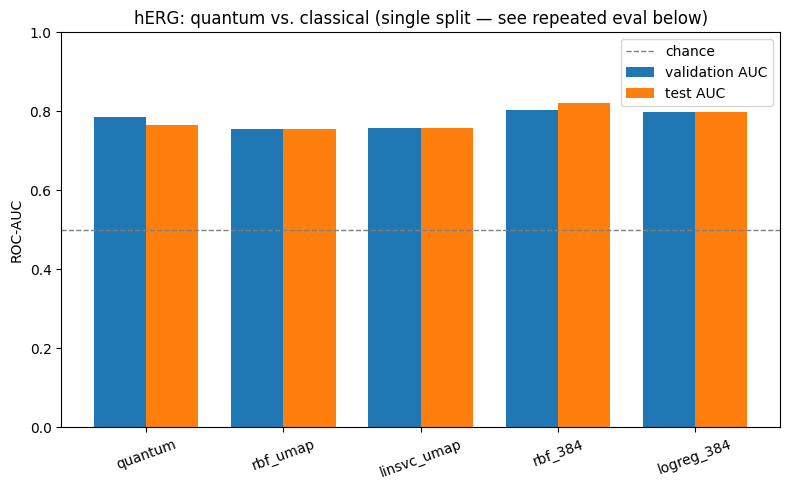

In [23]:
import matplotlib.pyplot as plt

names_m = ['quantum'] + [k for k in result.baseline]
val_auc  = [result.cv_auc_mean] + [result.baseline[k]['cv_auc_mean'] for k in result.baseline]
test_auc = [result.roc_auc]     + [result.baseline[k]['test_auc']    for k in result.baseline]

x = np.arange(len(names_m)); w = 0.38
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - w/2, val_auc,  w, label='validation AUC')
ax.bar(x + w/2, test_auc, w, label='test AUC')
ax.axhline(0.5, ls='--', c='grey', lw=1, label='chance')
ax.set_xticks(x); ax.set_xticklabels(names_m, rotation=20)
ax.set_ylabel('ROC-AUC'); ax.set_ylim(0, 1)
ax.set_title('hERG: quantum vs. classical (single split — see repeated eval below)')
ax.legend(); plt.tight_layout(); plt.show()

## 7b. Repeated splits (mean ± 95% CI)

With ~200 test points the AUC standard error is ~0.03, so a single split **cannot** tell
0.78 from 0.79. Any quantum-vs-classical claim must survive repeated splits. This reruns the
whole pipeline over several seeds (slower — reduce `n_samples`/`seeds` if needed).

In [31]:
from cardiotoxicity_pipeline import repeated_evaluation
from dataclasses import replace
# smaller working set keeps the repeat loop tractable; raise if you have time/GPU
eval_cfg = replace(config, n_samples=2000)
eval_s, eval_l, eval_n = load_herg_dataset(
    source='tdc', tdc_name='herg_central', tdc_label_name='hERG_inhib',
    n_samples=eval_cfg.n_samples, random_state=0) if not LOCAL_CSV else (smiles, labels, names)
summary = repeated_evaluation(eval_cfg, eval_s, eval_l, eval_n, seeds=(0, 1, 2, 3, 4, 5, 6 , 7, 8, 9))

Found local copy...
Loading...
Done!


Loading weights:   0%|          | 0/53 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: DeepChem/ChemBERTa-77M-MTR
Key                        | Status     | 
---------------------------+------------+-
norm_std                   | UNEXPECTED | 
regression.dense.bias      | UNEXPECTED | 
norm_mean                  | UNEXPECTED | 
regression.dense.weight    | UNEXPECTED | 
regression.out_proj.bias   | UNEXPECTED | 
regression.out_proj.weight | UNEXPECTED | 
pooler.dense.bias          | MISSING    | 
pooler.dense.weight        | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/53 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: DeepChem/ChemBERTa-77M-MTR
Key                        | Status     | 
---------------------------+------------+-
norm_std                   | UNEXPECTED | 
regression.dense.bias      | UNEXPECTED | 
norm_mean                  | UNEXPECTED | 
regression.dense.weight    | UNEXPECTED | 
regression.out_proj.bias   | UNEXPECTED | 
regression.out_proj.weight | UNEXPECTED | 
pooler.dense.bias          | MISSING    | 
pooler.dense.weight        | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Loading weights:   0%|          | 0/53 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: DeepChem/ChemBERTa-77M-MTR
Key                        | Status     | 
---------------------------+------------+-
norm_std                   | UNEXPECTED | 
regression.dense.bias      | UNEXPECTED | 
norm_mean                  | UNEXPECTED | 
regression.dense.weight    | UNEXPECTED | 
regression.out_proj.bias   | UNEXPECTED | 
regression.out_proj.weight | UNEXPECTED | 
pooler.dense.bias          | MISSING    | 
pooler.dense.weight        | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/53 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: DeepChem/ChemBERTa-77M-MTR
Key                        | Status     | 
---------------------------+------------+-
norm_std                   | UNEXPECTED | 
regression.dense.bias      | UNEXPECTED | 
norm_mean                  | UNEXPECTED | 
regression.dense.weight    | UNEXPECTED | 
regression.out_proj.bias   | UNEXPECTED | 
regression.out_proj.weight | UNEXPECTED | 
pooler.dense.bias          | MISSING    | 
pooler.dense.weight        | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



REPEATED EVALUATION over 10 splits -- test ROC-AUC (mean +/- 95% CI)
  quantum       0.7448 +/- 0.0155   (n=10)
  rbf_umap      0.7377 +/- 0.0165   (n=10)
  linsvc_umap   0.7459 +/- 0.0163   (n=10)
  rbf_384       0.8190 +/- 0.0097   (n=10)
  logreg_384    0.8178 +/- 0.0066   (n=10)


## 8. Quantum kernel heatmap

The selected quantum kernel (projected by default). A healthy kernel shows structure — not a
uniform block (too weak) or a bright diagonal on a dark field (concentrated). Rows/cols are
ordered `[train | test]`.

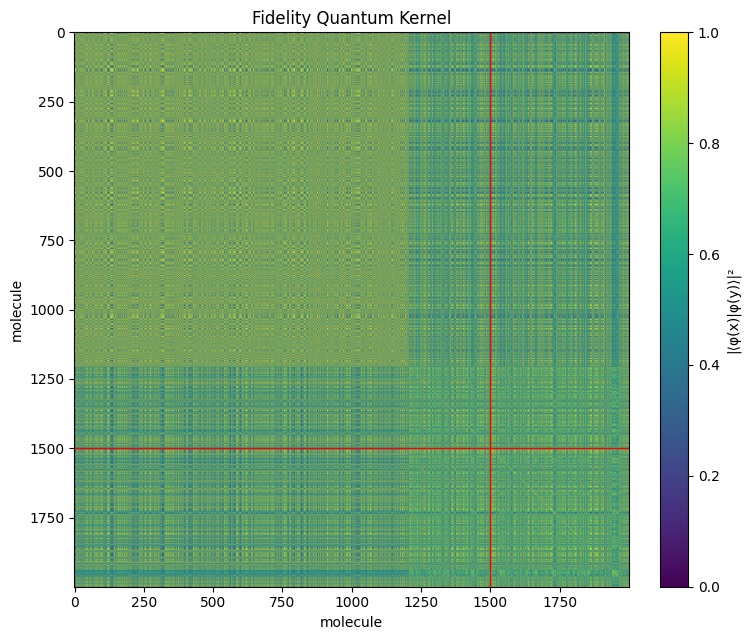

In [25]:
K = result.full_kernel
fig, ax = plt.subplots(figsize=(7.5, 6.5))
im = ax.imshow(K, cmap='viridis', vmin=0, vmax=1)
ax.axvline(result.n_train - 0.5, color='red', lw=1)
ax.axhline(result.n_train - 0.5, color='red', lw=1)
ax.set_title('Fidelity Quantum Kernel'); ax.set_xlabel('molecule'); ax.set_ylabel('molecule')
fig.colorbar(im, ax=ax, fraction=0.046, label='|⟨φ(x)|φ(y)⟩|²')
plt.tight_layout(); plt.show()

## 9. Molecule map — 2-D UMAP

2-D UMAP of the ChemBERTa embeddings, coloured by true hERG label, QSVC prediction, and
discovered structural sub-group.

Loading weights:   0%|          | 0/53 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: DeepChem/ChemBERTa-77M-MTR
Key                        | Status     | 
---------------------------+------------+-
norm_std                   | UNEXPECTED | 
regression.dense.bias      | UNEXPECTED | 
norm_mean                  | UNEXPECTED | 
regression.dense.weight    | UNEXPECTED | 
regression.out_proj.bias   | UNEXPECTED | 
regression.out_proj.weight | UNEXPECTED | 
pooler.dense.bias          | MISSING    | 
pooler.dense.weight        | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


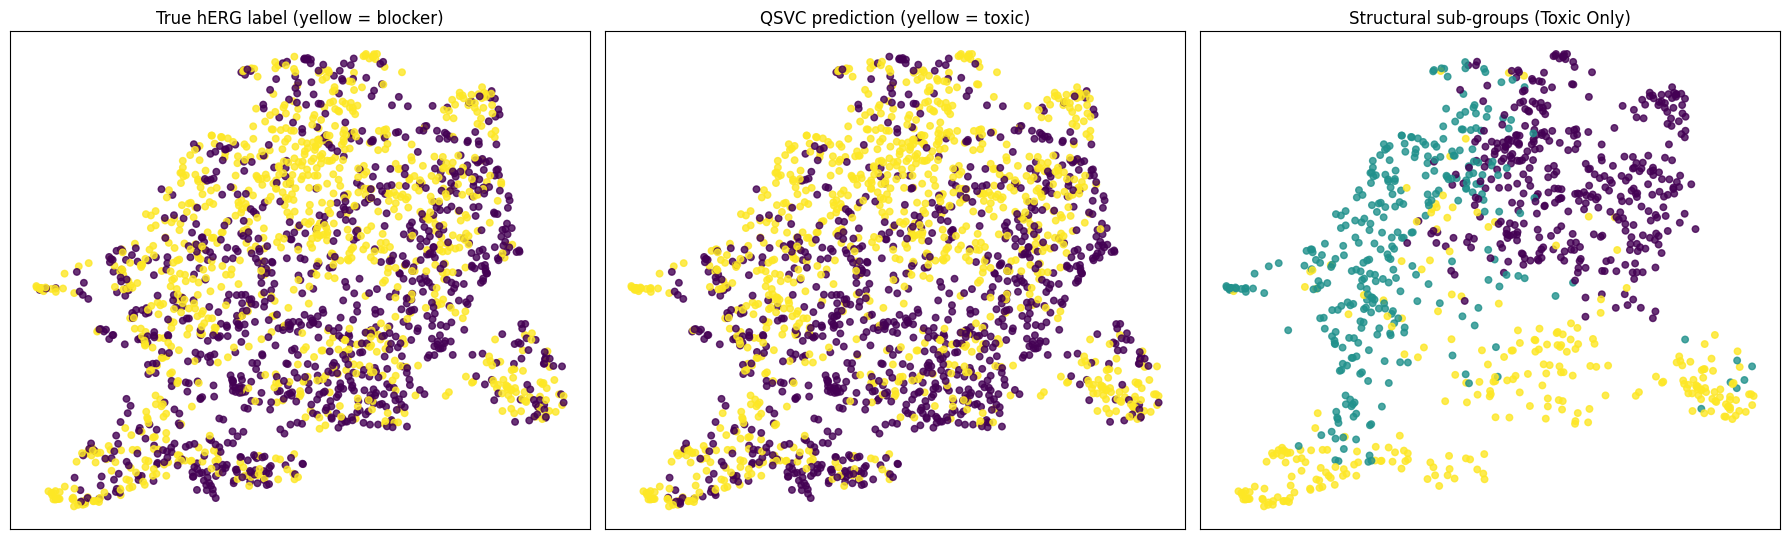

In [26]:
import umap
import matplotlib.pyplot as plt
import numpy as np

# Reuse embedder (ChemBERTa is cached)
pipe = ToxicityPipeline(config)
E = pipe.embedder.embed(smiles)
xy = umap.UMAP(n_neighbors=config.umap_n_neighbors, min_dist=0.1, n_components=2,
               metric='cosine', random_state=42).fit_transform(E)

pred_all = np.zeros(len(smiles), dtype=int)
pred_all[result.toxic_index] = 1

clust_all = np.full(len(smiles), -1, dtype=int)
if result.cluster_labels is not None:
    for did, c in zip(result.toxic_index, result.cluster_labels):
        clust_all[did] = c

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# Plot 1: True Labels
axes[0].scatter(xy[:, 0], xy[:, 1], c=labels, cmap='viridis', s=22, alpha=0.8)
axes[0].set_title('True hERG label (yellow = blocker)')

# Plot 2: QSVC Predictions
axes[1].scatter(xy[:, 0], xy[:, 1], c=pred_all, cmap='viridis', s=22, alpha=0.8)
axes[1].set_title('QSVC prediction (yellow = toxic)')

# Plot 3: Structural sub-groups (EXCLUDING predicted safe molecules)
toxic_mask = (clust_all != -1)
axes[2].scatter(xy[toxic_mask, 0], xy[toxic_mask, 1], c=clust_all[toxic_mask], cmap='viridis', s=22, alpha=0.8)
axes[2].set_title('Structural sub-groups (Toxic Only)')

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

## 10. Sanity check on named drugs (interpretability)

Run the trained pipeline logic on a small curated panel of named marketed drugs to see
whether known cardiotoxic drugs (Terfenadine, Dofetilide, …) are flagged and clustered
apart from safe drugs (Aspirin, Metformin, …).

In [27]:
from cardiotoxicity_pipeline import load_known_drug_panel
d_smiles, d_labels, d_names = load_known_drug_panel()
res_drugs = ToxicityPipeline(PipelineConfig(n_qubits=10, n_clusters=3,
                                            n_samples=None, run_classical_baseline=False)
                             ).run(d_smiles, d_labels, d_names)
test_ids = res_drugs.order[res_drugs.n_train:]
for pos, did in enumerate(test_ids):
    pred, truth = res_drugs.y_pred_test[pos], d_labels[did]
    flag = '✅' if pred == truth else '❌'
    print(f'  {flag} {d_names[did]:16s} pred={"Toxic" if pred else "Safe"}'
          f'  true={"Toxic" if truth else "Safe"}')

Loading weights:   0%|          | 0/53 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: DeepChem/ChemBERTa-77M-MTR
Key                        | Status     | 
---------------------------+------------+-
norm_std                   | UNEXPECTED | 
regression.dense.bias      | UNEXPECTED | 
norm_mean                  | UNEXPECTED | 
regression.dense.weight    | UNEXPECTED | 
regression.out_proj.bias   | UNEXPECTED | 
regression.out_proj.weight | UNEXPECTED | 
pooler.dense.bias          | MISSING    | 
pooler.dense.weight        | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  ✅ Caffeine         pred=Safe  true=Safe
  ✅ Cisapride        pred=Toxic  true=Toxic
  ✅ Vandetanib       pred=Toxic  true=Toxic
  ✅ Sotalol          pred=Toxic  true=Toxic
  ❌ Metronidazole    pred=Toxic  true=Safe
  ✅ Amiodarone       pred=Toxic  true=Toxic
  ✅ Amoxicillin      pred=Safe  true=Safe
  ❌ Fexofenadine     pred=Toxic  true=Safe


In [30]:
from cardiotoxicity_pipeline import PipelineConfig, load_herg_dataset, ToxicityPipeline, print_report

# 1. Push data limits and increase expressivity
config_large = PipelineConfig(
    n_samples=2000,              # Try 1000, 1500, or 2000
    max_quantum_samples=2500,    # Must be >= n_samples if you go above 2000
    n_qubits=10,                 # Bump up from 8 to 10 for better feature resolution
    feature_map_reps=3,          # Deeper quantum circuit (default is 2)
    random_state=36
)

# 2. Load the larger dataset
smiles_lg, labels_lg, names_lg = load_herg_dataset(
    source='tdc', tdc_name='herg_central', tdc_label_name='hERG_inhib',
    n_samples=config_large.n_samples, random_state=config_large.random_state
)

print(f"Loaded {len(smiles_lg)} samples. Running pipeline... (This might take a few minutes!)")

# 3. Run pipeline
# Uncomment the lines below to run the heavy experiment
result_large = ToxicityPipeline(config_large).run(smiles_lg, labels_lg, names_lg)
print_report(result_large)


Found local copy...
Loading...
Done!


Loaded 2000 samples. Running pipeline... (This might take a few minutes!)


Loading weights:   0%|          | 0/53 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: DeepChem/ChemBERTa-77M-MTR
Key                        | Status     | 
---------------------------+------------+-
norm_std                   | UNEXPECTED | 
regression.dense.bias      | UNEXPECTED | 
norm_mean                  | UNEXPECTED | 
regression.dense.weight    | UNEXPECTED | 
regression.out_proj.bias   | UNEXPECTED | 
regression.out_proj.weight | UNEXPECTED | 
pooler.dense.bias          | MISSING    | 
pooler.dense.weight        | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



STAGE 1 - QSVC CARDIOTOXICITY TRIAGE (quantum precomputed kernel)
              precision    recall  f1-score   support

    Safe (0)       0.77      0.61      0.68       250
   Toxic (1)       0.68      0.81      0.74       250

    accuracy                           0.71       500
   macro avg       0.72      0.71      0.71       500
weighted avg       0.72      0.71      0.71       500

Selected C        : 100
Feature map       : alpha=0.5 beta=0 gamma=0.5
Kernel health     : off-diag mean=0.7922  KTA=0.2605  g(K_C||K_Q)=5.65
Validation ROC-AUC: 0.7081  (leakage-free holdout; used for selection)
Decision threshold: 0.3479
Test Accuracy     : 0.7120
Test F1-Score     : 0.7382
Test ROC-AUC      : 0.7859

QUANTUM vs CLASSICAL  (*_umap = same UMAP features as quantum = fair
                       control; *_384 = ceiling on raw ChemBERTa embeddings)
model            val AUC   test AUC   test acc   test f1
quantum           0.7081     0.7859     0.7120    0.7382
rbf_umap          0.6956